# Measuring Cache Effectiveness

In [1]:
# Warning control
import warnings
warnings.filterwarnings('ignore')

## Setup Environment

In [3]:
# %load_ext autoreload
# %autoreload 2

import pandas as pd
import numpy as np
import time

from tqdm.auto import tqdm

from utils.cache.evals import CacheEvaluator
from utils.cache.faq_data_container import FAQDataContainer
from utils.cache.wrapper import SemanticCacheWrapper
from utils.cache.config import config, load_openai_key

print("Libraries imported successfully")

Libraries imported successfully


## Load Data and Recreate Cache

In [4]:
data_container = FAQDataContainer()
faq_df, test_df = data_container.faq_df, data_container.test_df

test_queries = test_df["question"].tolist()

Loaded 8 FAQ entries
Loaded 80 test queries


In [5]:
# Initialize semantic cache wrapper from config
cache_wrapper = SemanticCacheWrapper.from_config(config)

✅ Redis is running and accessible!
09:39:16 sentence_transformers.SentenceTransformer INFO   Use pytorch device_name: cpu
09:39:16 sentence_transformers.SentenceTransformer INFO   Load pretrained SentenceTransformer: redis/langcache-embed-v1


## Evaluating cache quality

In [6]:
# Cache hydration via wrapper helper
cache_wrapper.hydrate_from_df(faq_df)

cache_wrapper.check(faq_df["question"].iloc[0])

(Query: 'How do I get a refund?', Matches: ['How do I get a refund?'])

In [7]:
test_queries[:4]

["What's the process for getting my money back?",
 'How can I request a refund for my purchase?',
 'What steps do I follow to return an item for money back?',
 "What's your refund policy for digital products?"]

In [8]:
cache_results = cache_wrapper.check_many(test_queries)
cache_results[:4]

[(Query: 'What's the process for getting my money back?', Matches: ['How do I get a refund?']),
 (Query: 'How can I request a refund for my purchase?', Matches: ['How do I get a refund?']),
 (Query: 'What steps do I follow to return an item for money back?', Matches: ['How do I get a refund?']),
 (Query: 'What's your refund policy for digital products?', Matches: [])]

In [9]:
evaluator = CacheEvaluator(
    true_labels=data_container.label_cache_hits(cache_results),
    cache_results=cache_results,
)
evaluator.report_metrics()

Column
    [0] Markdown(str)
    [1] Row
        [0] DataFrame(DataFrame, width=200)
        [1] DataFrame(Styler)

In [10]:
[[tn, fp], [fn, tp]] = evaluator.get_metrics()["confusion_mask"]

In [11]:
tn[:9]

array([False, False, False,  True,  True, False,  True,  True,  True])

In [12]:
evaluator.matches_df()[fp]

,query,match,distance,true_label
5,Can I get a refund if I changed my mind?,How do I get a refund?,0.294378,False
24,Can I change my order after it's been placed?,Can I change my delivery address?,0.286985,False
53,How do I upgrade my subscription plan?,How do I cancel my subscription?,0.250155,False
55,Can I pause my subscription temporarily?,How do I cancel my subscription?,0.277127,False
75,Can I schedule a specific delivery time?,Can I change my delivery address?,0.286493,False


## Evaluating cache latency

In [13]:
def simulate_llm_call(prompt):
    time.sleep(np.random.uniform(0.2, 0.5))
    return f"LLM response to {prompt}"

In [14]:
from utils.cache.evals import PerfEval

perf_eval = PerfEval()

with perf_eval:
    for query in tqdm(test_queries):
        cache_wrapper.check(query)
        perf_eval.tick("cache_hit")
        perf_eval.start()
        simulate_llm_call(query)
        perf_eval.tick("llm_call")

metrics = perf_eval.get_metrics(labels=["cache_hit", "llm_call"])

100%|██████████| 80/80 [00:28<00:00,  2.78it/s]


In [15]:
metrics["by_label"]

{'cache_hit': {'count': 80,
  'average_latency': 5.909615755081177,
  'p50': 5.23984432220459,
  'p90': 7.820343971252443,
  'p95': 8.426034450531004,
  'p99': 16.05291366577144,
  'average_throughput': 169215.739473448},
 'llm_call': {'count': 80,
  'average_latency': 353.7912845611572,
  'p50': 368.2258129119873,
  'p90': 459.782099723816,
  'p95': 480.26756048202515,
  'p99': 487.4341440200805,
  'average_throughput': 2826.5252527076814}}

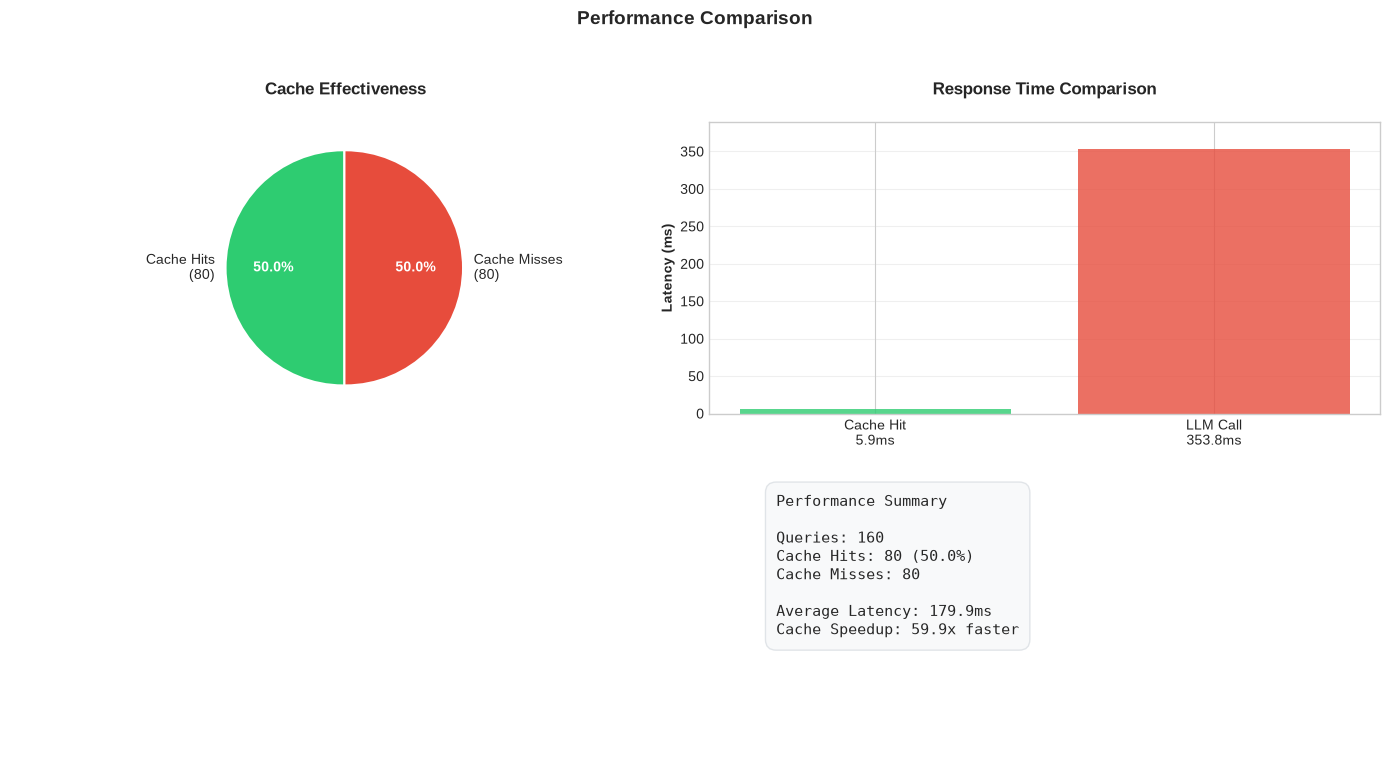

In [16]:
perf_eval.plot(
    title="Performance Comparison", show_cost_analysis=False
)

In [17]:
llm_latency = metrics["by_label"]["llm_call"]["average_latency"]
cache_latency = metrics["by_label"]["cache_hit"]["average_latency"]

cache_hit_rate = 0.3
cached_llm_latency = llm_latency * (1 - cache_hit_rate) + cache_latency * cache_hit_rate
cached_llm_drop_in_latency = (llm_latency - cached_llm_latency) / llm_latency
cached_llm_speedup = llm_latency / cached_llm_latency
print(f"Overall latency drop of an LLM app: {int(cached_llm_drop_in_latency * 100)}%")
print(f"Overall speedup of an LLM app {cached_llm_speedup:.2f}x")

Overall latency drop of an LLM app: 29%
Overall speedup of an LLM app 1.42x


## LLM-as-a-Judge for cache quality evaluation


In [18]:
cache_wrapper.hydrate_from_df(faq_df)

# we set the distance to obtain even bad matches and evaluate if they are true negatives
full_retrieval_nearest_neighbors = cache_wrapper.check_many(
    test_queries, distance_threshold=1
)
full_retrieval_matches = [h.matches[0].prompt for h in full_retrieval_nearest_neighbors]
full_retrieval_matches[:4]

['How do I get a refund?',
 'How do I get a refund?',
 'How do I get a refund?',
 'How do I get a refund?']

In [19]:
load_openai_key()

> OpenAI API key is already loaded in the environment


In [20]:
from utils.cache.llm_evaluator import LLMEvaluator

evaluator = LLMEvaluator.construct_with_gpt()

In [21]:
llm_similarity_results = evaluator.predict(
    dataset=zip(test_queries, full_retrieval_matches),
    batch_size=5,
)

  0%|          | 0/16 [00:00<?, ?it/s]

09:44:25 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:26 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:26 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:26 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:26 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


  6%|▋         | 1/16 [00:02<00:33,  2.22s/it]

09:44:27 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:27 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:27 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:27 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:27 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


 12%|█▎        | 2/16 [00:03<00:24,  1.78s/it]

...

 88%|████████▊ | 14/16 [00:22<00:02,  1.42s/it]

09:44:47 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:47 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:47 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:47 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:47 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


 94%|█████████▍| 15/16 [00:23<00:01,  1.41s/it]

09:44:48 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:48 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:48 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:48 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
09:44:49 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


100%|██████████| 16/16 [00:25<00:00,  1.57s/it]


In [22]:
llm_similarity_results.df.head()

,reason,is_similar
0,Both sentences are asking about the method or ...,True
1,Both sentences inquire about obtaining a refun...,True
2,Both sentences ask about the process or way to...,True
3,Sentence1 specifically asks about the refund p...,False
4,Sentence 1 asks about the cost associated with...,False


In [23]:
# When evaluation is based on full retrieval we should use this constructor
evaluator = CacheEvaluator.from_full_retrieval(
    true_labels=llm_similarity_results.df["is_similar"].values,
    cache_results=cache_wrapper.check_many(test_queries),
)
evaluator.report_metrics()

Column
    [0] Markdown(str)
    [1] Row
        [0] DataFrame(DataFrame, width=200)
        [1] DataFrame(Styler)